In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Install (run once) cell 1
# ══════════════════════════════════════════════════════════════
# Install compatible PyTorch and Torchvision for CUDA 12.1
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Install other core dependencies
!pip install -q -U bitsandbytes>=0.46.1 transformers>=4.37.2 accelerate

Mounted at /drive
Upload your MRI image:


Saving WhatsApp Image 2026-05-14 at 6.19.32 PM (1).jpeg to WhatsApp Image 2026-05-14 at 6.19.32 PM (1).jpeg
Loaded image: WhatsApp Image 2026-05-14 at 6.19.32 PM (1).jpeg
Image size: 400 x 369


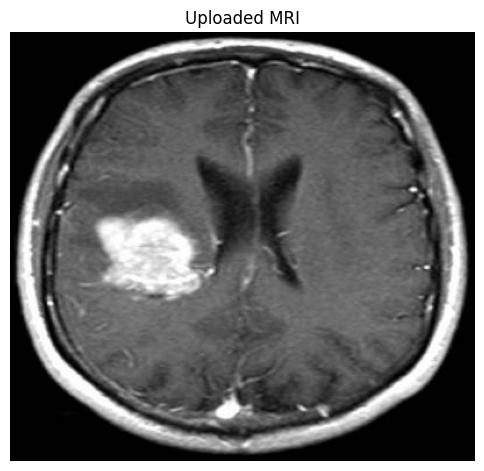

Loading MedGemma...


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GPU used: 5.52 GB


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tumor present: yes
MedGemma bbox response: ```json
{"tumor_present": true, "x_min": 35, "y_min": 35, "x_max": 65, "y_max": 70, "size": "medium"}
```
Parsed: {'tumor_present': True, 'x_min': 35, 'y_min': 35, 'x_max': 65, 'y_max': 70, 'size': 'medium'}
Tight tumor box: (140,129) → (260,258)
Center: (200,193)


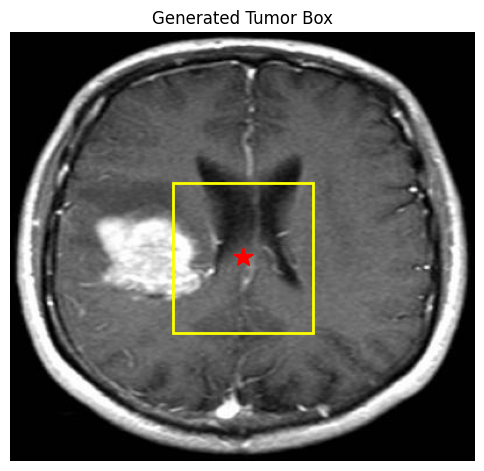

✅ Saved JSON to /drive/MyDrive/tumor_data.json
Now run Cell 4.


In [ ]:
# CELL 2 — Install For image download and checking(run once)

import torch, gc, json, re
from transformers import pipeline, BitsAndBytesConfig
from PIL import Image
from google.colab import drive, userdata, files
from huggingface_hub import login
import matplotlib.pyplot as plt
import matplotlib.patches as patches

drive.mount('/drive', force_remount=True)

torch.cuda.empty_cache()
gc.collect()

login(userdata.get("HF_TOKEN"))

print("Upload your MRI image:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Loaded image:", image_path)

image_pil = Image.open(image_path).convert("RGB")
W, H = image_pil.size
print(f"Image size: {W} x {H}")

# Save same image to Drive
saved_image_path = "/drive/MyDrive/current_mri.png"
image_pil.save(saved_image_path)

plt.figure(figsize=(6, 6))
plt.imshow(image_pil)
plt.title("Uploaded MRI")
plt.axis("off")
plt.show()

print("Loading MedGemma...")
quantization_config = BitsAndBytesConfig(load_in_4bit=True)

pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-1.5-4b-it",
    device_map="auto",
    model_kwargs={"quantization_config": quantization_config},
)

print(f"GPU used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# STEP 1: Tumor presence
detection_messages = [
    {
        "role": "system",
        "content": [{
            "type": "text",
            "text": (
                "You are a medical imaging AI assistant. "
                "Determine whether a brain tumor is present. "
                "Reply only Yes or No."
            )
        }]
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_pil},
            {"type": "text", "text": "Is there a tumor in this T1-weighted brain MRI?"}
        ]
    }
]

output = pipe(text=detection_messages, max_new_tokens=5)
presence = output[0]["generated_text"][-1]["content"].strip().lower()
print("Tumor present:", presence)

if "no" in presence:
    with open("/drive/MyDrive/tumor_data.json", "w") as f:
        json.dump({"tumor_present": False}, f)
    print("No tumor detected.")

else:
    # STEP 2: Tight tumor bounding box in percentage
    location_messages = [
        {
            "role": "system",
            "content": [{
                "type": "text",
                "text": (
                    "You are an expert neuroradiologist. "
                    "Find only the brain tumor region, not skull, scalp, brain edge, or normal cortex. "
                    "Return a tight bounding box around the tumor only. "
                    "Use percentages from 0 to 100 of image width and height. "
                    "Respond ONLY in this JSON format: "
                    '{"tumor_present": true, "x_min": 35, "y_min": 35, "x_max": 65, "y_max": 70, "size": "medium"} '
                    "size must be small, medium, or large. "
                    "Do not include skull or outer head boundary."
                )
            }]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_pil},
                {"type": "text", "text": "Give the tight tumor bounding box only as JSON."}
            ]
        }
    ]

    output2 = pipe(text=location_messages, max_new_tokens=80)
    response = output2[0]["generated_text"][-1]["content"].strip()
    print("MedGemma bbox response:", response)

    json_match = re.search(r"\{.*?\}", response, re.DOTALL)
    if not json_match:
        raise ValueError("Could not parse MedGemma JSON: " + response)

    loc = json.loads(json_match.group())
    print("Parsed:", loc)

    x_min = float(loc.get("x_min", 35))
    y_min = float(loc.get("y_min", 35))
    x_max = float(loc.get("x_max", 65))
    y_max = float(loc.get("y_max", 70))
    size = loc.get("size", "medium")

    # Convert percentage to pixels
    x1 = int((x_min / 100) * W)
    y1 = int((y_min / 100) * H)
    x2 = int((x_max / 100) * W)
    y2 = int((y_max / 100) * H)

    # Safety correction
    x1 = max(5, min(x1, W - 10))
    y1 = max(5, min(y1, H - 10))
    x2 = max(x1 + 30, min(x2, W - 5))
    y2 = max(y1 + 30, min(y2, H - 5))

    cx = int((x1 + x2) / 2)
    cy = int((y1 + y2) / 2)

    print(f"Tight tumor box: ({x1},{y1}) \u2192 ({x2},{y2})")
    print(f"Center: ({cx},{cy})")

    save_data = {
        "tumor_present": True,
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,
        "cx": cx,
        "cy": cy,
        "size": size,
        "W": int(W),
        "H": int(H),
        "image_path": saved_image_path,
        "box_source": "medgemma_tight_percent_bbox"
    }

    with open("/drive/MyDrive/tumor_data.json", "w") as f:
        json.dump(save_data, f)

    # Show generated box
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_pil)

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="yellow",
        facecolor="none"
    )

    ax.add_patch(rect)
    ax.plot(cx, cy, "r*", markersize=15)
    ax.set_title("Generated Tumor Box")
    ax.axis("off")
    plt.show()

    print("\u2705 Saved JSON to /drive/MyDrive/tumor_data.json")
    print("Now run Cell 4.")

In [ ]:
# THIS IS FOR THE MODEL(this is for figshare dataset) run once
!mkdir brain_dataset
%cd brain_dataset

# Download dataset (REAL MRI with tumors)
!wget https://ndownloader.figshare.com/articles/1512427/versions/5 -O data.zip

# Extract
!unzip -q data.zip

# Fix split zip files
!cat brainTumorDataPublic_* > combined.zip
!zip -FF combined.zip --out fixed.zip

# Extract final dataset
!unzip -q fixed.zip -d data

print("✅ Done")

mkdir: cannot create directory ‘brain_dataset’: File exists
/content/brain_dataset
--2026-05-15 11:05:25--  https://ndownloader.figshare.com/articles/1512427/versions/5
Resolving ndownloader.figshare.com (ndownloader.figshare.com)... 54.76.73.74, 108.132.92.120, 54.77.146.63, ...
Connecting to ndownloader.figshare.com (ndownloader.figshare.com)|54.76.73.74|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 879501695 (839M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>] 838.76M  26.7MB/s    in 33s     

2026-05-15 11:05:59 (25.4 MB/s) - ‘data.zip’ saved [879501695/879501695]

replace brainTumorDataPublic_1-766.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
Fix archive (-FF) - salvage what can
	zip warning: Missing end (EOCDR) signature - either this archive
                     is not readable or the end is damaged
Is this a single-disk archive?  (y/n): 

zip error: Interrupted (aborting)
replace data/1533.mat? [y]es, [n]o, 

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Dataset folder
mat_dir = "/content/brain_dataset/data"

# Get MAT files
files = [f for f in os.listdir(mat_dir) if f.endswith(".mat")]

print("Total files:", len(files))

# Show first 5 samples
sample_files = files[:5]

for file in sample_files:

    path = os.path.join(mat_dir, file)

    try:
        # Open MATLAB v7.3 file
        with h5py.File(path, 'r') as f:

            # Read image and mask
            img = np.array(f['cjdata']['image'])
            mask = np.array(f['cjdata']['tumorMask'])

            # Rotate properly
            img = np.rot90(img)
            mask = np.rot90(mask)



    except Exception as e:
        print("Error reading:", file)
        print(e)

Total files: 3064


In [ ]:
#This is for kaggle lgg-mri-segmentation run once
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
lgg-mri-segmentation.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
#This is for kaggle lgg-mri-segmentation (run once)

!unzip -q "/content/brain_dataset/lgg-mri-segmentation.zip" -d "/content/brain_dataset/lgg_dataset"

In [ ]:
import os
print(os.listdir("/content/brain_dataset"))

['combined.zip', 'data.zip', 'tumor.jpg', 'cvind.mat', 'lgg-mri-segmentation.zip', 'brainTumorDataPublic_1533-2298.zip', 'data', 'brainTumorDataPublic_1-766.zip', 'lgg_dataset1', 'README.txt', 'brainTumorDataPublic_767-1532.zip', 'fixed.zip', 'lgg_dataset', 'brainTumorDataPublic_2299-3064.zip']


In [ ]:
# This is combining both LGG segmentation and Figshare for training the model (run once)
import os
import cv2
import shutil
import numpy as np
import h5py # New import for handling .mat files
import scipy.io # New import for handling .mat files

# =========================================================
# LGG DATASET
# =========================================================

lgg_base_dir = "/content/brain_dataset/lgg_dataset1/lgg-mri-segmentation/kaggle_3m"

# =========================================================
# FINAL COMBINED DATASET
# =========================================================

combined_img_dir = "/content/final_dataset/images"
combined_mask_dir = "/content/final_dataset/masks"

os.makedirs(combined_img_dir, exist_ok=True)
os.makedirs(combined_mask_dir, exist_ok=True)

# =========================================================
# COUNTER
# =========================================================

count = 0

# =========================================================
# PROCESS FIGSHARE DATASET (MAT to PNG)
# =========================================================

print("Processing Figshare dataset (MAT to PNG)...")

fig_mat_dir = "/content/brain_dataset/data" # Directory containing .mat files

# Check if the directory exists and contains .mat files
if not os.path.exists(fig_mat_dir) or not any(f.endswith(".mat") for f in os.listdir(fig_mat_dir)):
    print(f"❌ Figshare .mat data not found at {fig_mat_dir}. Please ensure cell fjrxhpKs6Z0E has run successfully.")
else:
    mat_files = [f for f in os.listdir(fig_mat_dir) if f.endswith(".mat")]
    mat_files.sort() # Ensure consistent order

    for file in mat_files:
        mat_path = os.path.join(fig_mat_dir, file)

        img = None
        mask = None

        # =================================================
        # TRY SCIPY LOADER
        # =================================================

        try:
            data = scipy.io.loadmat(mat_path)
            img = data["cjdata"]["image"][0][0]
            mask = data["cjdata"]["tumorMask"][0][0]
        except Exception:
            # =================================================
            # FALLBACK TO H5PY FOR MATLAB v7.3
            # =================================================
            try:
                with h5py.File(mat_path, "r") as f:
                    cjdata = f["cjdata"]
                    img = np.array(cjdata["image"])
                    mask = np.array(cjdata["tumorMask"])
                    # Apply rotation if needed, based on typical .mat structures
                    img = np.rot90(img)
                    mask = np.rot90(mask)
            except Exception as e:
                print(f"❌ Error processing {file}: {e}")
                continue

        if img is None or mask is None:
            print(f"❌ Could not extract image/mask from {file}")
            continue

        # =================================================
        # NORMALIZE AND RESIZE IMAGE
        # =================================================
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        img = cv2.resize(img, (128,128), interpolation=cv2.INTER_AREA)

        # =================================================
        # RESIZE MASK AND ENSURE BINARY
        # =================================================
        mask = cv2.resize(mask, (128,128), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.uint8) * 255 # Ensure mask is binary (0 or 255)

        # =================================================
        # SAVE IMAGE AND MASK
        # =================================================
        cv2.imwrite(f"{combined_img_dir}/{count}.png", img)
        cv2.imwrite(f"{combined_mask_dir}/{count}.png", mask)
        count += 1

print("✅ Figshare processed and copied")

# =========================================================
# COPY LGG DATASET
# =========================================================

print("Copying LGG dataset...")

for root, dirs, files in os.walk(lgg_base_dir):

    for file in files:

        # =================================================
# MRI IMAGE
# =================================================

        if file.endswith(".tif") and "_mask" not in file:

            img_path = os.path.join(
                root,
                file
            )

            mask_path = img_path.replace(
                ".tif",
                "_mask.tif"
            )

            # =================================================
# CHECK MASK
# =================================================

            if not os.path.exists(mask_path):
                continue

            # =================================================
# LOAD
# =================================================

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            mask = cv2.imread(
                mask_path,
                cv2.IMREAD_GRAYSCALE
            )

            if img is None or mask is None:
                continue

            # =================================================
# RESIZE
# =================================================

            img = cv2.resize(
                img,
                (128,128)
            )

            mask = cv2.resize(
                mask,
                (128,128)
            )

            # =================================================
# BINARY MASK
# =================================================

            mask = (
                mask > 0
            ).astype(np.uint8) * 255

            # =================================================
# SAVE
# =================================================

            cv2.imwrite(
                f"{combined_img_dir}/{count}.png",
                img
            )

            cv2.imwrite(
                f"{combined_mask_dir}/{count}.png",
                mask
            )

            count += 1

# =========================================================
# FINAL OUTPUT
# =========================================================

print("✅ FINAL DATASET CREATED")

print("Total combined images:", count)

print("Images folder:", combined_img_dir)

print("Masks folder:", combined_mask_dir)

Processing Figshare dataset (MAT to PNG)...
✅ Figshare processed and copied
Copying LGG dataset...
✅ FINAL DATASET CREATED
Total combined images: 6993
Images folder: /content/final_dataset/images
Masks folder: /content/final_dataset/masks


In [ ]:
# =========================================================
# 🧠 FINAL IMPROVED U-NET TRAINING PIPELINE
# Brain Tumor Segmentation
# Compatible with Figshare Brain Tumor Dataset
# =========================================================

# =========================================================
# INSTALL REQUIRED PACKAGES
# =========================================================

!pip install -q h5py scipy

# =========================================================
# IMPORTS
# =========================================================

import os
import cv2
import h5py
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

# =========================================================
# DEVICE
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

# =========================================================
# RANDOM SEED
# =========================================================

torch.manual_seed(42)
np.random.seed(42)

# =========================================================
# DATASET PATHS
# =========================================================

mat_dir = "/content/final_dataset/data"

img_dir = "/content/final_dataset/images"
mask_dir = "/content/final_dataset/masks"

os.makedirs(img_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

# =========================================================
# DOWNLOAD DATASET IF MISSING
# =========================================================

if not os.path.exists(mat_dir):

    print("Downloading dataset...")

    os.chdir("/content")

    !mkdir -p brain_dataset

    %cd brain_dataset

    !wget -nc https://ndownloader.figshare.com/articles/1512427/versions/5 -O data.zip

    !unzip -o -q data.zip

    !cat brainTumorDataPublic_* > combined.zip

    !zip -FF combined.zip --out fixed.zip

    !unzip -o -q fixed.zip -d data

    os.chdir("/content")

    print("✅ Dataset ready")

# =========================================================
# CONVERT MAT FILES TO PNG
# =========================================================

if len(os.listdir(img_dir)) == 0:

    print("Converting MAT files...")

    count = 0

    files = os.listdir(mat_dir)

    for file in files:

        if not file.endswith(".mat"):
            continue

        path = os.path.join(mat_dir, file)

        img = None
        mask = None

        # =================================================
        # TRY SCIPY LOADER
        # =================================================

        try:

            data = scipy.io.loadmat(path)

            img = data["cjdata"]["image"][0][0]

            mask = data["cjdata"]["tumorMask"][0][0]

        # =================================================
        # FALLBACK TO H5PY FOR MATLAB v7.3
        # =================================================

        except:

            try:

                with h5py.File(path, "r") as f:

                    cjdata = f["cjdata"]

                    img = np.array(
                        cjdata["image"]
                    )

                    mask = np.array(
                        cjdata["tumorMask"]
                    )

                    img = np.rot90(img)

                    mask = np.rot90(mask)

            except Exception as e:

                print("❌ Error:", file)

                print(e)

                continue

        # =================================================
        # NORMALIZE IMAGE
        # =================================================

        img = cv2.normalize(
            img,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        )

        img = cv2.resize(
            img,
            (128,128),
            interpolation=cv2.INTER_AREA
        ).astype(np.uint8)

        # =================================================
        # PROCESS MASK
        # =================================================

        mask = cv2.resize(
            mask,
            (128,128),
            interpolation=cv2.INTER_NEAREST
        )

        mask = (mask > 0).astype(np.uint8)

        # =================================================
        # SAVE
        # =================================================

        cv2.imwrite(
            f"{img_dir}/{count}.png",
            img
        )

        cv2.imwrite(
            f"{mask_dir}/{count}.png",
            mask * 255
        )

        count += 1

    print("✅ Converted:", count)

# =========================================================
# DATASET VALIDATION
# =========================================================

print("\n🔍 Checking Dataset Integrity...")

imgs = sorted(os.listdir(img_dir))
masks = sorted(os.listdir(mask_dir))

print("Images :", len(imgs))
print("Masks  :", len(masks))

assert len(imgs) == len(masks), "Mismatch between images and masks"

bad_files = 0
empty_masks = 0

for i in range(len(imgs)):

    img_path = os.path.join(img_dir, imgs[i])
    mask_path = os.path.join(mask_dir, masks[i])

    img = cv2.imread(img_path, 0)
    mask = cv2.imread(mask_path, 0)

    # =================================================
    # CHECK READABILITY
    # =================================================

    if img is None or mask is None:

        print("❌ Corrupted:", imgs[i])

        bad_files += 1

        continue

    # =================================================
    # CHECK SHAPES
    # =================================================

    if img.shape != mask.shape:

        print("❌ Shape mismatch:", imgs[i])

        bad_files += 1

    # =================================================
    # CHECK EMPTY MASK
    # =================================================

    if np.sum(mask) == 0:

        empty_masks += 1

    # =================================================
    # CHECK BINARY MASK
    # =================================================

    unique_vals = np.unique(mask)

    if len(unique_vals) > 2:

        print("⚠ Non-binary mask:", imgs[i])

print("\n==========================")
print("✅ VALIDATION COMPLETE")
print("==========================")

print("Bad Files   :", bad_files)
print("Empty Masks :", empty_masks)

# =========================================================
# SHOW SAMPLE IMAGES
# =========================================================

print("\n🖼 Showing Dataset Samples...")

indices = np.random.choice(len(imgs), 3)

for idx in indices:

    img = cv2.imread(
        os.path.join(img_dir, imgs[idx]),
        0
    )

    mask = cv2.imread(
        os.path.join(mask_dir, masks[idx]),
        0
    )


# =========================================================
# DATASET CLASS
# =========================================================

class BrainDataset(Dataset):

    def __init__(self, img_dir, mask_dir):

        self.imgs = sorted(
            os.listdir(img_dir),
            key=lambda x: int(x.split(".")[0])
        )

        self.img_dir = img_dir
        self.mask_dir = mask_dir

    def __len__(self):

        return len(self.imgs)

    def __getitem__(self, idx):

        name = self.imgs[idx]

        img_path = os.path.join(
            self.img_dir,
            name
        )

        mask_path = os.path.join(
            self.mask_dir,
            name
        )

        img = cv2.imread(img_path, 0)

        mask = cv2.imread(mask_path, 0)

        # =================================================
        # AUGMENTATION
        # =================================================

        if np.random.rand() > 0.5:

            img = cv2.GaussianBlur(
                img,
                (3,3),
                0
            )

        if np.random.rand() > 0.5:

            img = cv2.flip(img, 1)

            mask = cv2.flip(mask, 1)

        # =================================================
        # NORMALIZE
        # =================================================

        img = img / 255.0

        mask = mask / 255.0

        # =================================================
        # TO TENSOR
        # =================================================

        img = torch.tensor(
            img,
            dtype=torch.float32
        ).unsqueeze(0)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return img, mask

# =========================================================
# LOAD DATASET
# =========================================================

dataset = BrainDataset(
    img_dir,
    mask_dir
)

train_size = int(0.8 * len(dataset))

val_size = len(dataset) - train_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\n✅ Dataset Loaded")

print("Train Samples      :", len(train_ds))

print("Validation Samples :", len(val_ds))

# =========================================================
# U-NET MODEL
# =========================================================

class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        def block(in_c, out_c):

            return nn.Sequential(

                nn.Conv2d(
                    in_c,
                    out_c,
                    3,
                    padding=1
                ),

                nn.BatchNorm2d(out_c),

                nn.ReLU(inplace=True),

                nn.Conv2d(
                    out_c,
                    out_c,
                    3,
                    padding=1
                ),

                nn.BatchNorm2d(out_c),

                nn.ReLU(inplace=True)
            )

        self.enc1 = block(1, 64)

        self.pool = nn.MaxPool2d(2)

        self.enc2 = block(64, 128)

        self.enc3 = block(128, 256)

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=False
        )

        self.dec1 = block(
            256 + 128,
            128
        )

        self.dec2 = block(
            128 + 64,
            64
        )

        self.out = nn.Conv2d(
            64,
            1,
            1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        d1 = self.up(e3)

        d1 = torch.cat(
            [d1, e2],
            dim=1
        )

        d1 = self.dec1(d1)

        d2 = self.up(d1)

        d2 = torch.cat(
            [d2, e1],
            dim=1
        )

        d2 = self.dec2(d2)

        out = self.out(d2)

        return out

# =========================================================
# CREATE MODEL
# =========================================================

model = UNet().to(device)

print("\n✅ U-Net Created")

# =========================================================
# LOSS FUNCTIONS
# =========================================================

pos_weight = torch.tensor([2.5]).to(device)

bce = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

def dice_loss(
    pred,
    target,
    smooth=1
):

    pred = torch.sigmoid(pred)

    pred = pred.view(-1)

    target = target.view(-1)

    intersection = (
        pred * target
    ).sum()

    dice = (
        2.0 * intersection + smooth
    ) / (
        pred.sum() +
        target.sum() +
        smooth
    )

    return 1 - dice

class ComboLoss(nn.Module):

    def __init__(self):

        super().__init__()

    def forward(
        self,
        pred,
        target
    ):

        return (
            bce(pred, target)
            +
            dice_loss(pred, target)
        )

loss_fn = ComboLoss()

# =========================================================
# DICE SCORE
# =========================================================

def dice_score(pred, target):

    pred = torch.sigmoid(pred)

    pred = (pred > 0.5).float()

    pred = pred.view(-1)

    target = target.view(-1)

    intersection = (
        pred * target
    ).sum()

    dice = (
        2 * intersection + 1
    ) / (
        pred.sum() +
        target.sum() + 1
    )

    return dice.item()

# =========================================================
# OPTIMIZER
# =========================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# =========================================================
# MIXED PRECISION
# =========================================================

use_amp = device == "cuda"

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

# =========================================================
# TRAINING
# =========================================================

best_loss = 999999

epochs = 20

print("\n🚀 Training Started")

for epoch in range(epochs):

    # =================================================
    # TRAIN
    # =================================================

    model.train()

    train_loss = 0

    for imgs, masks in train_loader:

        imgs = imgs.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(
            "cuda",
            enabled=use_amp
        ):

            preds = model(imgs)

            loss = loss_fn(
                preds,
                masks
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        train_loss += loss.item()

    # =================================================
    # VALIDATION
    # =================================================

    model.eval()

    val_loss = 0

    dice_total = 0

    with torch.no_grad():

        for imgs, masks in val_loader:

            imgs = imgs.to(device)

            masks = masks.to(device)

            preds = model(imgs)

            loss = loss_fn(
                preds,
                masks
            )

            val_loss += loss.item()

            dice_total += dice_score(
                preds,
                masks
            )

    # =================================================
    # AVERAGE METRICS
    # =================================================

    train_loss /= len(train_loader)

    val_loss /= len(val_loader)

    avg_dice = dice_total / len(val_loader)

    # =================================================
    # PRINT RESULTS
    # =================================================

    print(
        f"Epoch {epoch+1}/{epochs}"
        f" | Train Loss: {train_loss:.4f}"
        f" | Val Loss: {val_loss:.4f}"
        f" | Dice Score: {avg_dice:.4f}"
    )

    # =================================================
    # SAVE BEST MODEL
    # =================================================

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            model.state_dict(),
            "/content/best_model.pth"
        )

        print("💾 Best model saved")

print("\n✅ TRAINING COMPLETE")

print("📦 Model saved at: /content/best_model.pth")

Using device: cuda
/content/brain_dataset
File ‘data.zip’ already there; not retrieving.
Fix archive (-FF) - salvage what can
 Found end record (EOCDR) - says expect single disk archive
Scanning for entries...
 copying: 1533.mat  (339637 bytes)
 copying: 1534.mat  (340418 bytes)
 copying: 1535.mat  (342222 bytes)
 copying: 1536.mat  (342920 bytes)
 copying: 1537.mat  (343484 bytes)
 copying: 1538.mat  (323526 bytes)
 copying: 1539.mat  (326770 bytes)
 copying: 1540.mat  (328641 bytes)
 copying: 1541.mat  (331088 bytes)
 copying: 1542.mat  (333075 bytes)
 copying: 1543.mat  (335548 bytes)
 copying: 1544.mat  (337196 bytes)
 copying: 1545.mat  (265792 bytes)
 copying: 1546.mat  (266357 bytes)
 copying: 1547.mat  (267792 bytes)
 copying: 1548.mat  (269198 bytes)
 copying: 1549.mat  (267728 bytes)
 copying: 1550.mat  (265932 bytes)
 copying: 1551.mat  (264956 bytes)
 copying: 1552.mat  (262235 bytes)
 copying: 1553.mat  (262966 bytes)
 copying: 1554.mat  (263969 bytes)
 copying: 1555.mat  

Using device: cuda
✅ Model Loaded


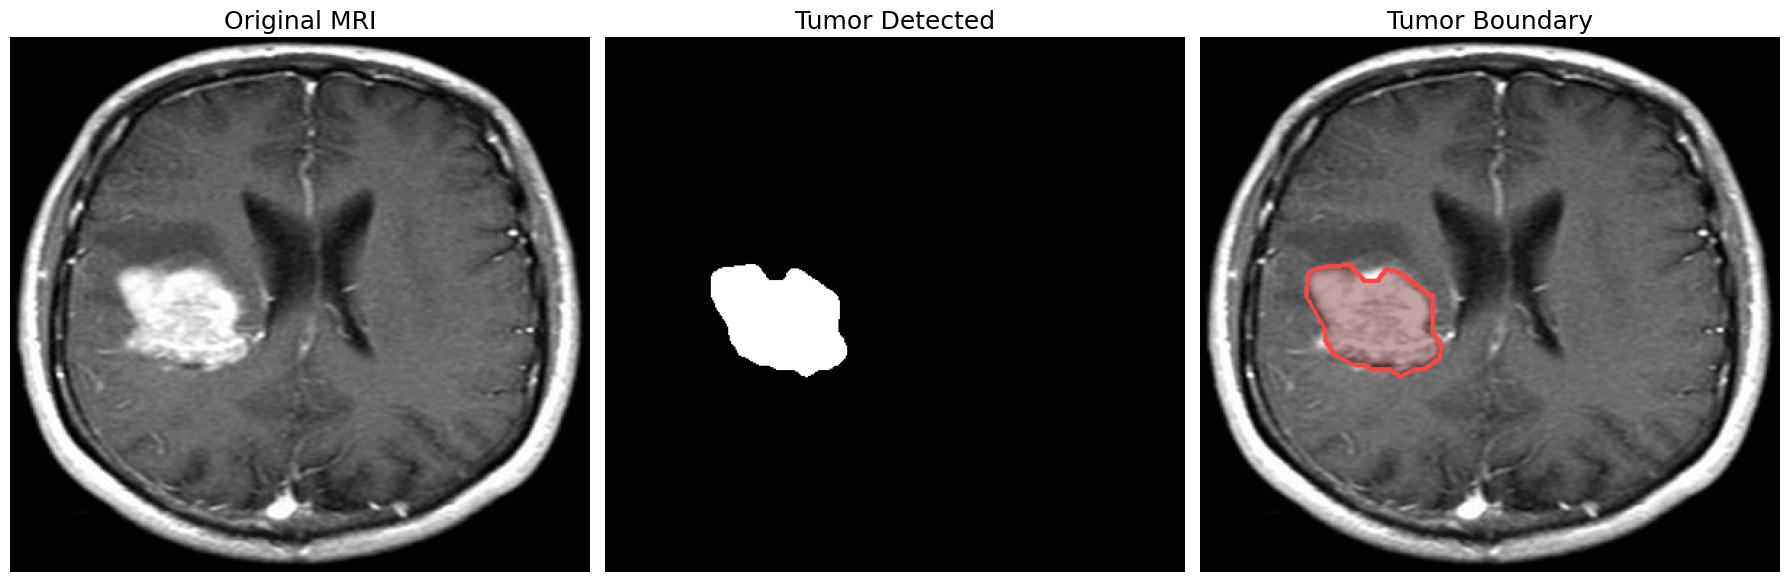


Prediction      : Tumor Detected
Tumor Pixels    : 5236

✅ Boundary image saved
✅ Mask saved
✅ Numpy mask saved
✅ Last tumor image saved


In [ ]:

# 🧠 SINGLE MRI INFERENCE + TUMOR BOUNDARY
# YOUR TRAINED U-NET MODEL
# =========================================================

import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

# =========================================================
# U-NET MODEL
# =========================================================

class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        def block(in_c, out_c):

            return nn.Sequential(

                nn.Conv2d(
                    in_c,
                    out_c,
                    3,
                    padding=1
                ),

                nn.BatchNorm2d(out_c),

                nn.ReLU(inplace=True),

                nn.Conv2d(
                    out_c,
                    out_c,
                    3,
                    padding=1
                ),

                nn.BatchNorm2d(out_c),

                nn.ReLU(inplace=True)
            )

        self.enc1 = block(1, 64)

        self.pool = nn.MaxPool2d(2)

        self.enc2 = block(64, 128)

        self.enc3 = block(128, 256)

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=False
        )

        self.dec1 = block(
            256 + 128,
            128
        )

        self.dec2 = block(
            128 + 64,
            64
        )

        self.out = nn.Conv2d(
            64,
            1,
            1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        d1 = self.up(e3)

        d1 = nn.functional.interpolate(
            d1,
            size=e2.shape[2:]
        )

        d1 = torch.cat(
            [d1, e2],
            dim=1
        )

        d1 = self.dec1(d1)

        d2 = self.up(d1)

        d2 = nn.functional.interpolate(
            d2,
            size=e1.shape[2:]
        )

        d2 = torch.cat(
            [d2, e1],
            dim=1
        )

        d2 = self.dec2(d2)

        return self.out(d2)

# =========================================================
# LOAD MODEL
# =========================================================

model = UNet().to(device)

model.load_state_dict(
    torch.load(
        "/content/best_model.pth",
        map_location=device
    )
)

model.eval()

print("✅ Model Loaded")

# =========================================================
# INPUT MRI IMAGE
# =========================================================

img_path = "/drive/MyDrive/current_mri.png"

img = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)

if img is None:

    raise ValueError(
        "❌ MRI IMAGE NOT FOUND"
    )

original = img.copy()

H, W = img.shape

# =========================================================
# PREPROCESS
# =========================================================

img_resized = cv2.resize(
    img,
    (128,128),
    interpolation=cv2.INTER_AREA
)

img_norm = img_resized / 255.0

input_tensor = torch.tensor(
    img_norm,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0).to(device)

# =========================================================
# MODEL PREDICTION
# =========================================================

with torch.no_grad():

    pred = model(input_tensor)

    pred = torch.sigmoid(pred)

    pred = pred.cpu().squeeze().numpy()

# =========================================================
# RESIZE PREDICTION
# =========================================================

pred = cv2.resize(
    pred,
    (W, H),
    interpolation=cv2.INTER_LINEAR
)

# =========================================================
# SEGMENTATION
# =========================================================

threshold = (
    np.mean(pred)
    + 0.45 * np.std(pred)
)

mask = (
    pred > threshold
).astype(np.uint8)

# =========================================================
# CLEAN MASK
# =========================================================

kernel = np.ones((5,5), np.uint8)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

mask = cv2.GaussianBlur(
    mask.astype(np.float32),
    (11,11),
    0
)

mask = (
    mask > 0.3
).astype(np.uint8)

# =========================================================
# KEEP LARGEST REGION
# =========================================================

num_labels, labels, stats, _ = \
    cv2.connectedComponentsWithStats(mask)

if num_labels > 1:

    largest = (
        1 +
        np.argmax(
            stats[1:, cv2.CC_STAT_AREA]
        )
    )

    mask = (
        labels == largest
    ).astype(np.uint8)

# =========================================================
# DETECTION LOGIC
# =========================================================

tumor_pixels = np.sum(mask)

threshold_pixels = 100

predicted_label = (
    "Tumor Detected"
    if tumor_pixels > threshold_pixels
    else "No Tumor Detected"
)

# =========================================================
# FIND CONTOURS
# =========================================================

contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

# =========================================================
# SMOOTH CONTOURS
# =========================================================

smooth_contours = []

for cnt in contours:

    epsilon = (
        0.004 *
        cv2.arcLength(cnt, True)
    )

    smooth = cv2.approxPolyDP(
        cnt,
        epsilon,
        True
    )

    smooth_contours.append(smooth)

# =========================================================
# CREATE OUTPUT IMAGE
# =========================================================

final = cv2.cvtColor(
    original,
    cv2.COLOR_GRAY2BGR
)

# =========================================================
# TUMOR OVERLAY
# =========================================================

tumor_overlay = final.copy()

cv2.drawContours(
    tumor_overlay,
    smooth_contours,
    -1,
    (0,0,90),
    thickness=cv2.FILLED
)

final = cv2.addWeighted(
    tumor_overlay,
    0.35,
    final,
    0.65,
    0
)

# =========================================================
# THIN BOUNDARY
# =========================================================

cv2.drawContours(
    final,
    smooth_contours,
    -1,
    (70,70,255),
    2
)



# =========================================================
# SAVE OUTPUTS
# =========================================================

cv2.imwrite(
    "/content/final_boundary.png",
    final
)

cv2.imwrite(
    "/content/final_mask.png",
    mask * 255
)

np.save(
    "/content/final_mask.npy",
    mask
)

# =========================================================
# DISPLAY
# =========================================================

plt.figure(figsize=(18,7))

# ---------------------------------------------------------
# ORIGINAL MRI
# ---------------------------------------------------------

plt.subplot(1,3,1)

plt.title(
    "Original MRI",
    fontsize=18
)

plt.imshow(
    original,
    cmap="gray"
)

plt.axis("off")

# ---------------------------------------------------------
# PREDICTED MASK
# ---------------------------------------------------------

plt.subplot(1,3,2)

plt.title(
    predicted_label,
    fontsize=18
)

plt.imshow(
    mask,
    cmap="gray"
)

plt.axis("off")

# ---------------------------------------------------------
# FINAL BOUNDARY
# ---------------------------------------------------------

plt.subplot(1,3,3)

plt.title(
    "Tumor Boundary",
    fontsize=18
)

final_rgb = cv2.cvtColor(
    final,
    cv2.COLOR_BGR2RGB
)

plt.imshow(final_rgb)

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================================
# FINAL INFO
# =========================================================

print("\n==============================")

print("Prediction      :", predicted_label)

print("Tumor Pixels    :", tumor_pixels)

print("==============================")

print("\n✅ Boundary image saved")
print("✅ Mask saved")
print("✅ Numpy mask saved")
# =========================================================
# SAVE LAST TUMOR IMAGE ONLY
# =========================================================

plt.imsave(
    "/content/last_tumor_output.png",
    final_rgb
)

print("✅ Last tumor image saved")

Using device: cuda
✅ MRI Loaded
✅ U-Net Model Loaded

Prediction Statistics
Min : 1.4193915e-13
Max : 0.9999746
Mean: 0.030313462

✅ Tumor Center: (120, 194)


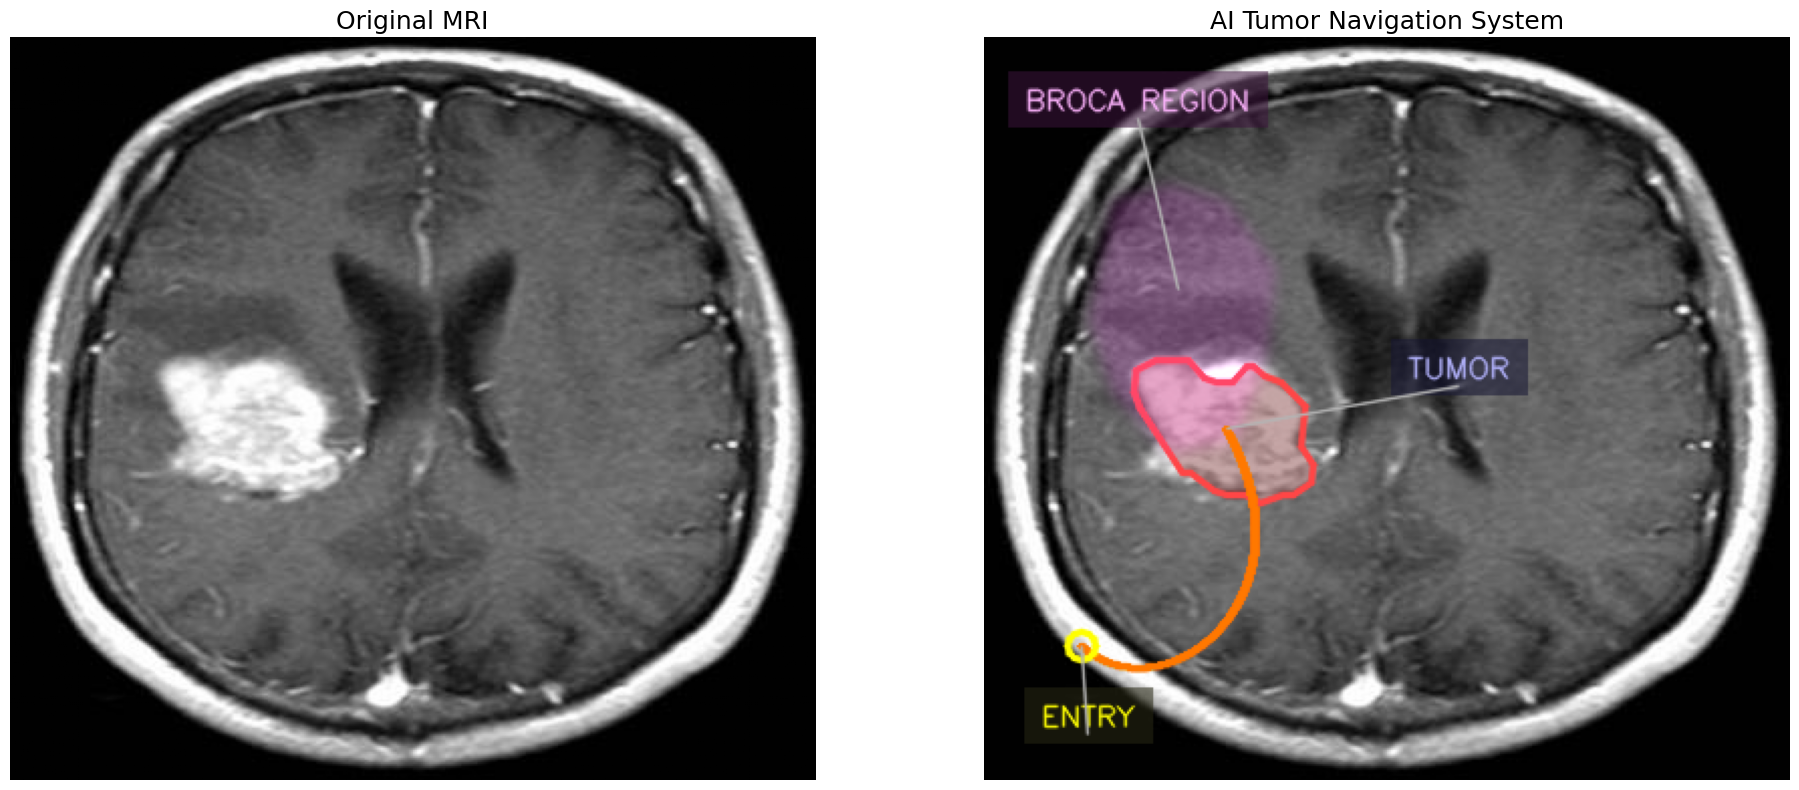


✅ AI navigation generated
✅ Probe created from U-Net segmentation
✅ Predicted mask saved
✅ Output saved to: /content/final_ai_navigation.png


In [ ]:
# =========================================================
# 🧠 AI MRI TUMOR NAVIGATION SYSTEM
# U-NET SEGMENTATION + AUTO PROBE GENERATION
# =========================================================

import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

# =========================================================
# MRI IMAGE PATH
# =========================================================

image_path = "/drive/MyDrive/current_mri.png"

if not os.path.exists(image_path):

    raise FileNotFoundError(
        f"❌ MRI image not found:\n{image_path}"
    )

# =========================================================
# LOAD MRI IMAGE
# =========================================================

img = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)

if img is None:

    raise ValueError(
        "❌ Could not load MRI image"
    )

print("✅ MRI Loaded")

original = img.copy()

H, W = img.shape

# =========================================================
# U-NET MODEL
# =========================================================

class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        def block(in_c, out_c):

            return nn.Sequential(

                nn.Conv2d(
                    in_c,
                    out_c,
                    3,
                    padding=1
                ),

                nn.BatchNorm2d(out_c),

                nn.ReLU(inplace=True),

                nn.Conv2d(
                    out_c,
                    out_c,
                    3,
                    padding=1
                ),

                nn.BatchNorm2d(out_c),

                nn.ReLU(inplace=True)
            )

        self.enc1 = block(1, 64)

        self.pool = nn.MaxPool2d(2)

        self.enc2 = block(64, 128)

        self.enc3 = block(128, 256)

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=False
        )

        self.dec1 = block(
            256 + 128,
            128
        )

        self.dec2 = block(
            128 + 64,
            64
        )

        self.out = nn.Conv2d(
            64,
            1,
            1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        d1 = self.up(e3)

        d1 = nn.functional.interpolate(
            d1,
            size=e2.shape[2:]
        )

        d1 = torch.cat(
            [d1, e2],
            dim=1
        )

        d1 = self.dec1(d1)

        d2 = self.up(d1)

        d2 = nn.functional.interpolate(
            d2,
            size=e1.shape[2:]
        )

        d2 = torch.cat(
            [d2, e1],
            dim=1
        )

        d2 = self.dec2(d2)

        return self.out(d2)

# =========================================================
# LOAD TRAINED MODEL
# =========================================================

model = UNet().to(device)

MODEL_PATH = "/content/best_model.pth"

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        f"❌ Model not found:\n{MODEL_PATH}"
    )

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("✅ U-Net Model Loaded")

# =========================================================
# PREPROCESS MRI
# =========================================================

INPUT_SIZE = 128

img_resized = cv2.resize(
    img,
    (INPUT_SIZE, INPUT_SIZE)
)

img_norm = img_resized / 255.0

input_tensor = torch.tensor(
    img_norm,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0).to(device)

# =========================================================
# MODEL PREDICTION
# =========================================================

with torch.no_grad():

    pred = torch.sigmoid(
        model(input_tensor)
    ).cpu().squeeze().numpy()

print("\nPrediction Statistics")

print("Min :", pred.min())
print("Max :", pred.max())
print("Mean:", pred.mean())

# =========================================================
# RESIZE PREDICTION
# =========================================================

pred = cv2.resize(
    pred,
    (W, H)
)

# =========================================================
# SEGMENTATION
# =========================================================

threshold = 0.5

mask = (
    pred > threshold
).astype(np.uint8)

# =========================================================
# CLEAN MASK
# =========================================================

kernel = np.ones((5,5), np.uint8)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

mask = cv2.GaussianBlur(
    mask.astype(np.float32),
    (11,11),
    0
)

mask = (
    mask > 0.3
).astype(np.uint8)

# =========================================================
# KEEP LARGEST REGION
# =========================================================

num_labels, labels, stats, _ = \
    cv2.connectedComponentsWithStats(mask)

if num_labels > 1:

    largest = (
        1 +
        np.argmax(
            stats[1:, cv2.CC_STAT_AREA]
        )
    )

    mask = (
        labels == largest
    ).astype(np.uint8)

# =========================================================
# TUMOR CENTER FROM MODEL
# =========================================================

ys, xs = np.where(mask > 0)

if len(xs) > 0:

    center_x = int(np.mean(xs))

    center_y = int(np.mean(ys))

    print(
        f"\n✅ Tumor Center:"
        f" ({center_x}, {center_y})"
    )

else:

    raise ValueError(
        "❌ No tumor detected by model"
    )

# =========================================================
# FIND CONTOURS
# =========================================================

contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

smooth_contours = []

for cnt in contours:

    epsilon = (
        0.004 *
        cv2.arcLength(cnt, True)
    )

    smooth = cv2.approxPolyDP(
        cnt,
        epsilon,
        True
    )

    smooth_contours.append(smooth)

# =========================================================
# CREATE OUTPUT IMAGE
# =========================================================

final = cv2.cvtColor(
    original,
    cv2.COLOR_GRAY2BGR
)

# =========================================================
# TUMOR OVERLAY
# =========================================================

overlay = final.copy()

cv2.drawContours(
    overlay,
    smooth_contours,
    -1,
    (0,0,90),
    thickness=cv2.FILLED
)

final = cv2.addWeighted(
    overlay,
    0.35,
    final,
    0.65,
    0
)

# =========================================================
# TUMOR OUTLINE
# =========================================================

cv2.drawContours(
    final,
    smooth_contours,
    -1,
    (70,70,255),
    2,
    lineType=cv2.LINE_AA
)

# =========================================================
# BROCA REGION
# =========================================================

broca_pts = np.array([

    [int(W * 0.16), int(H * 0.22)],
    [int(W * 0.23), int(H * 0.20)],
    [int(W * 0.30), int(H * 0.22)],
    [int(W * 0.36), int(H * 0.31)],
    [int(W * 0.35), int(H * 0.43)],
    [int(W * 0.31), int(H * 0.54)],
    [int(W * 0.23), int(H * 0.56)],
    [int(W * 0.16), int(H * 0.48)],
    [int(W * 0.13), int(H * 0.38)]

], np.int32)

broca_pts = broca_pts.reshape((-1,1,2))

# =========================================================
# BROCA OVERLAY
# =========================================================

broca_mask = np.zeros(
    (H, W),
    dtype=np.uint8
)

cv2.fillPoly(
    broca_mask,
    [broca_pts],
    255
)

broca_mask = cv2.GaussianBlur(
    broca_mask,
    (21,21),
    0
)

purple_layer = np.zeros_like(final)

purple_layer[:,:,0] = broca_mask * 0.75
purple_layer[:,:,2] = broca_mask * 0.75

final = cv2.addWeighted(
    final,
    1.0,
    purple_layer,
    0.18,
    0
)

# =========================================================
# ENTRY POINT
# =========================================================

entry_x = int(W * 0.12)
entry_y = int(H * 0.82)

# =========================================================
# BEZIER CONTROL POINTS
# =========================================================

p0 = np.array([
    entry_x,
    entry_y
])

p1 = np.array([
    int(W * 0.22),
    int(H * 0.92)
])

p2 = np.array([
    int(W * 0.42),
    int(H * 0.76)
])

p3 = np.array([
    center_x,
    center_y
])

# =========================================================
# GENERATE PROBE CURVE
# =========================================================

curve_points = []

for t in np.linspace(0, 1, 1000):

    point = (
        ((1 - t) ** 3) * p0 +
        3 * ((1 - t) ** 2) * t * p1 +
        3 * (1 - t) * (t ** 2) * p2 +
        (t ** 3) * p3
    )

    x = int(point[0])
    y = int(point[1])

    if 0 <= x < W and 0 <= y < H:

        curve_points.append((x, y))

# =========================================================
# DRAW THIN SINGLE PROBE
# =========================================================

for i in range(len(curve_points)-1):

    cv2.line(
        final,
        curve_points[i],
        curve_points[i+1],
        (0,120,255),
        2,
        lineType=cv2.LINE_AA
    )

# =========================================================
# ENTRY POINT
# =========================================================

cv2.circle(
    final,
    (entry_x, entry_y),
    7,
    (0,255,255),
    2,
    lineType=cv2.LINE_AA
)

# =========================================================
# LABEL FUNCTION
# =========================================================

def draw_label(

    image,
    text,
    text_pos,
    target_pos,
    box_color=(30,30,30),
    text_color=(255,255,255)

):

    font = cv2.FONT_HERSHEY_SIMPLEX

    font_scale = 0.48

    thickness = 1

    (tw, th), _ = cv2.getTextSize(
        text,
        font,
        font_scale,
        thickness
    )

    padding = 8

    x, y = text_pos

    overlay = image.copy()

    cv2.rectangle(
        overlay,
        (x-padding, y-th-padding),
        (x+tw+padding, y+padding),
        box_color,
        -1
    )

    image[:] = cv2.addWeighted(
        overlay,
        0.55,
        image,
        0.45,
        0
    )

    cv2.putText(
        image,
        text,
        (x,y),
        font,
        font_scale,
        text_color,
        thickness,
        lineType=cv2.LINE_AA
    )

    cv2.line(
        image,
        (x + tw//2, y + 4),
        target_pos,
        (180,180,180),
        1,
        lineType=cv2.LINE_AA
    )

# =========================================================
# LABELS
# =========================================================

draw_label(

    final,
    "BROCA REGION",

    text_pos=(
        int(W * 0.05),
        int(H * 0.10)
    ),

    target_pos=(
        int(W * 0.24),
        int(H * 0.34)
    ),

    box_color=(60,20,60),
    text_color=(255,180,255)
)

draw_label(

    final,
    "ENTRY",

    text_pos=(
        entry_x - 20,
        entry_y + 40
    ),

    target_pos=(
        entry_x,
        entry_y
    ),

    box_color=(20,40,40),
    text_color=(0,255,255)
)

draw_label(

    final,
    "TUMOR",

    text_pos=(
        center_x + 90,
        center_y - 25
    ),

    target_pos=(
        center_x,
        center_y
    ),

    box_color=(50,20,20),
    text_color=(255,180,180)
)

# =========================================================
# DISPLAY
# =========================================================

plt.figure(figsize=(20,8))

# ---------------------------------------------------------
# ORIGINAL MRI
# ---------------------------------------------------------

plt.subplot(1,2,1)

plt.title(
    "Original MRI",
    fontsize=18
)

plt.imshow(
    original,
    cmap="gray"
)

plt.axis("off")

# ---------------------------------------------------------
# AI NAVIGATION
# ---------------------------------------------------------

plt.subplot(1,2,2)

plt.title(
    "AI Tumor Navigation System",
    fontsize=18
)

final_rgb = cv2.cvtColor(
    final,
    cv2.COLOR_BGR2RGB
)

plt.imshow(final_rgb)

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================================
# SAVE OUTPUTS
# =========================================================

output_path = "/content/final_ai_navigation.png"

cv2.imwrite(
    output_path,
    final
)

cv2.imwrite(
    "/content/predicted_mask.png",
    mask * 255
)

print("\n✅ AI navigation generated")
print("✅ Probe created from U-Net segmentation")
print("✅ Predicted mask saved")
print(f"✅ Output saved to: {output_path}")